In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Maths ', 'Colab Notebooks', 'Annual Calendar.gsheet', 'Monthly budget.gsheet', 'To-do list (3).gsheet', 'To-do list (2).gsheet', 'To-do list (1).gsheet', 'Annual budget.gsheet', '24 5 To-do list.gsheet', 'To-do list.gsheet', 'Birthday Month for Shivam.gsite', 'Chest_Xray_Pneumonia_Project']


In [ ]:
project_path = "/content/drive/MyDrive/Chest_Xray_Pneumonia_Project"

print(os.path.exists(project_path))

True


In [ ]:
dataset_path = project_path + "/dataset/chest_xray"

print(os.listdir(dataset_path))

['train', 'test', 'chest_xray', '__MACOSX', 'val']


In [ ]:
print("TRAIN:", os.listdir(dataset_path + "/train"))
print("TEST:", os.listdir(dataset_path + "/test"))
print("VAL:", os.listdir(dataset_path + "/val"))

TRAIN: ['NORMAL', 'PNEUMONIA']
TEST: ['PNEUMONIA', 'NORMAL']
VAL: ['PNEUMONIA', 'NORMAL']


In [ ]:
train_normal = os.listdir(dataset_path + "/train/NORMAL")
train_pneumonia = os.listdir(dataset_path + "/train/PNEUMONIA")

test_normal = os.listdir(dataset_path + "/test/NORMAL")
test_pneumonia = os.listdir(dataset_path + "/test/PNEUMONIA")

val_normal = os.listdir(dataset_path + "/val/NORMAL")
val_pneumonia = os.listdir(dataset_path + "/val/PNEUMONIA")

print("Training Normal:", len(train_normal))
print("Training Pneumonia:", len(train_pneumonia))

print("Testing Normal:", len(test_normal))
print("Testing Pneumonia:", len(test_pneumonia))

print("Validation Normal:", len(val_normal))
print("Validation Pneumonia:", len(val_pneumonia))

Training Normal: 1341
Training Pneumonia: 3875
Testing Normal: 234
Testing Pneumonia: 390
Validation Normal: 8
Validation Pneumonia: 8


Image size: (1940, 1503)


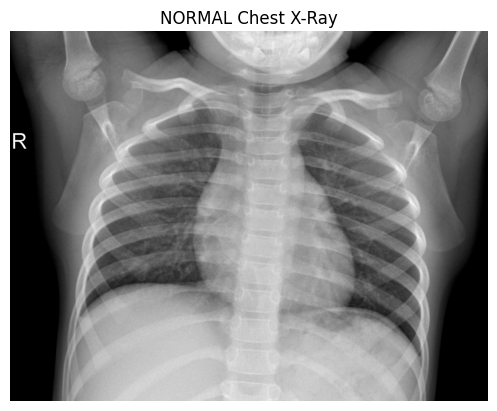

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

normal_image_path = dataset_path + "/train/NORMAL/" + train_normal[0]

img = Image.open(normal_image_path)

print("Image size:", img.size)

plt.imshow(img, cmap="gray")
plt.title("NORMAL Chest X-Ray")
plt.axis("off")
plt.show()

Image size: (1136, 888)


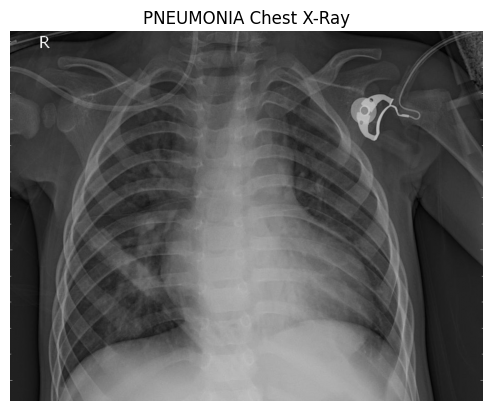

In [ ]:
pneumonia_image_path = dataset_path + "/train/PNEUMONIA/" + train_pneumonia[0]

img = Image.open(pneumonia_image_path)

print("Image size:", img.size)

plt.imshow(img, cmap="gray")
plt.title("PNEUMONIA Chest X-Ray")
plt.axis("off")
plt.show()

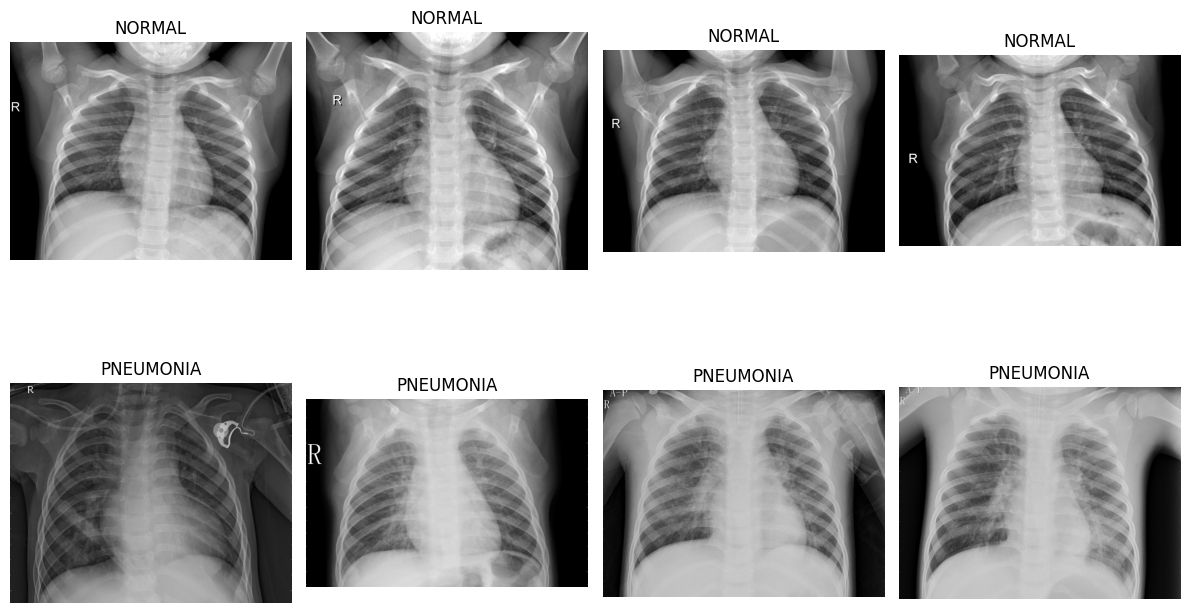

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(4):
    img_path = dataset_path + "/train/NORMAL/" + train_normal[i]
    img = Image.open(img_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")

for i in range(4):
    img_path = dataset_path + "/train/PNEUMONIA/" + train_pneumonia[i]
    img = Image.open(img_path)

    plt.subplot(2, 4, i + 5)
    plt.imshow(img, cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


In [ ]:
img_height = 180
img_width = 180
batch_size = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path + "/train",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 5216 files belonging to 2 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path + "/val",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 16 files belonging to 2 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path + "/test",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 624 files belonging to 2 classes.


In [ ]:
class_names = train_ds.class_names

print(class_names)

['NORMAL', 'PNEUMONIA']


In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 180, 180, 3)
Label batch shape: (32,)


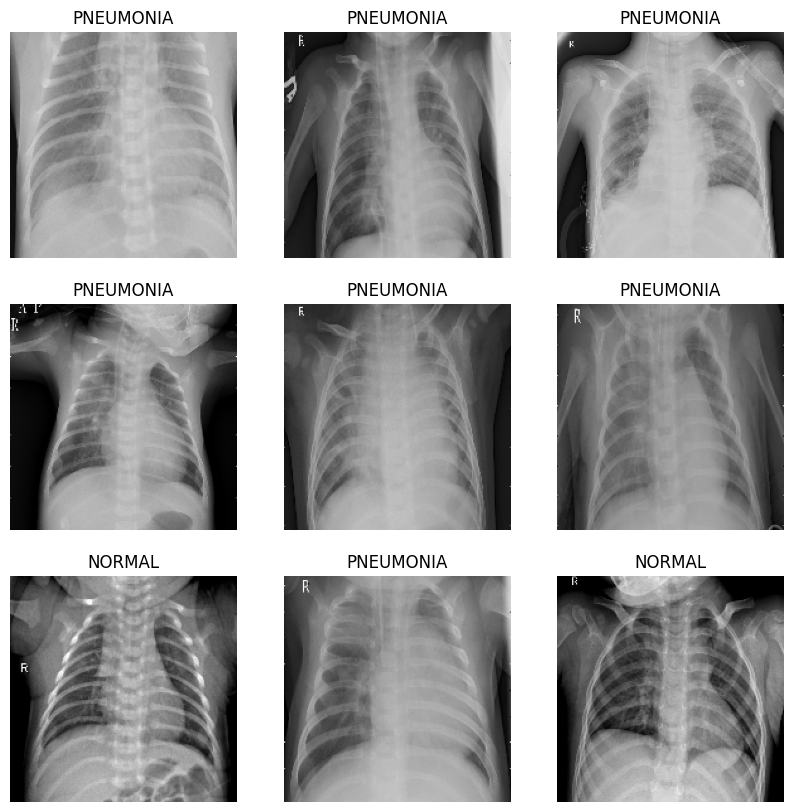

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print(class_names)

['NORMAL', 'PNEUMONIA']


In [ ]:
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,898 (15.22 MB)

 Trainable params: 3,988,898 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 237ms/step - accuracy: 0.8583 - loss: 9.8036 - val_accuracy: 0.8750 - val_loss: 0.3754
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 247ms/step - accuracy: 0.9492 - loss: 0.1461 - val_accuracy: 0.8125 - val_loss: 0.4254
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 253ms/step - accuracy: 0.9607 - loss: 0.1005 - val_accuracy: 0.9375 - val_loss: 0.0852
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 38s 230ms/step - accuracy: 0.9636 - loss: 0.0913 - val_accuracy: 0.9375 - val_loss: 0.0785
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.9747 - loss: 0.0727 - val_accuracy: 0.7500 - val_loss: 0.7187
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 237ms/step - accuracy: 0.9783 - loss: 0.0542 - val_accuracy: 1.0000 - val_loss: 0.0289
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 240ms/step - accuracy: 0.9789 - loss: 0.0549 - val_accuracy: 0.7500 - val_loss: 0.4964
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 39s 230ms/step - accuracy: 0.9829 - loss: 0

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


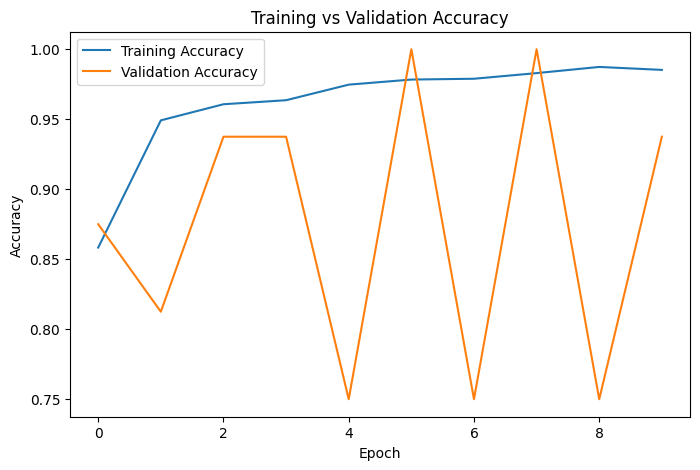

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

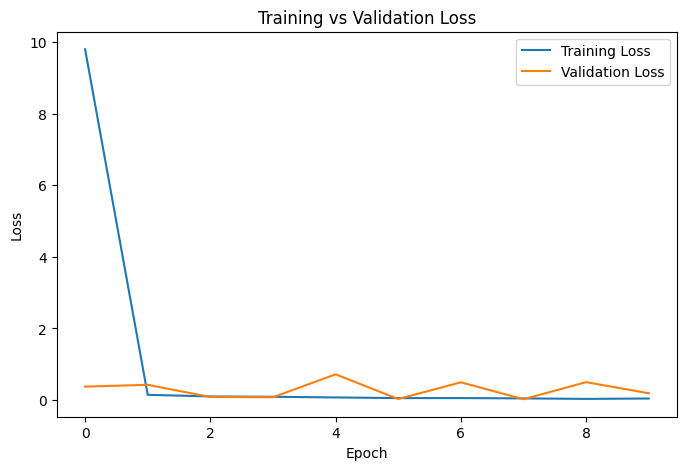

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.7516 - loss: 1.8888
Test Loss: 1.8887789249420166
Test Accuracy: 0.7516025900840759


In [ ]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)

In [ ]:
base_model.trainable = False

In [ ]:
resnet_model = keras.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(2, activation="softmax")
])

In [ ]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
resnet_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 6, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 266ms/step - accuracy: 0.8324 - loss: 0.4084 - val_accuracy: 0.8750 - val_loss: 0.2502
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 252ms/step - accuracy: 0.9110 - loss: 0.2188 - val_accuracy: 0.8750 - val_loss: 0.2900
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 250ms/step - accuracy: 0.9293 - loss: 0.1823 - val_accuracy: 0.8750 - val_loss: 0.3115


In [ ]:
resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(test_ds)

print("ResNet Test Loss:", resnet_test_loss)
print("ResNet Test Accuracy:", resnet_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.8269 - loss: 0.3890
ResNet Test Loss: 0.3889847993850708
ResNet Test Accuracy: 0.8269230723381042


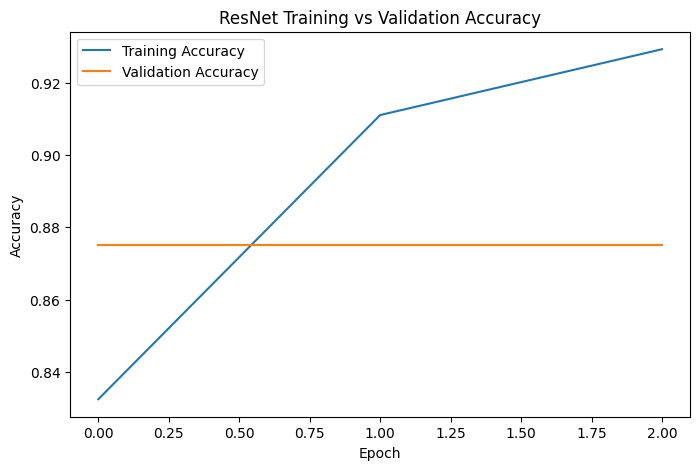

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    resnet_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet Training vs Validation Accuracy")
plt.legend()

plt.show()

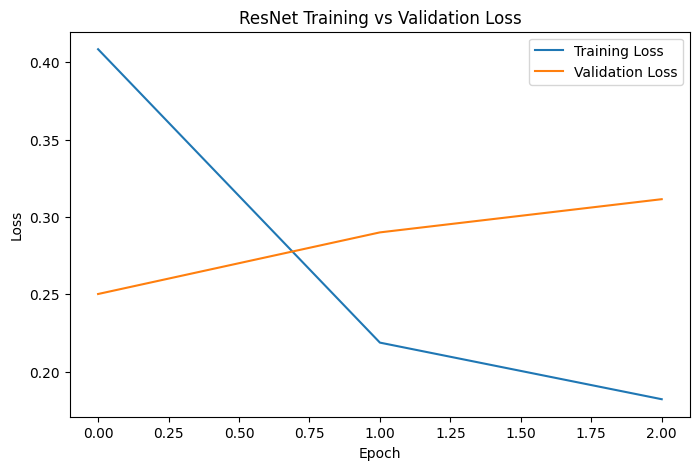

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    resnet_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    resnet_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
base_model.trainable = True

In [ ]:
fine_tune_at = 140

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
trainable_layers = sum(
    1 for layer in base_model.layers if layer.trainable
)

print("Trainable layers:", trainable_layers)

Trainable layers: 35


In [ ]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
fine_tune_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[fine_tune_early_stopping]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 304ms/step - accuracy: 0.9321 - loss: 0.1697 - val_accuracy: 0.9375 - val_loss: 0.1313
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 256ms/step - accuracy: 0.9676 - loss: 0.0855 - val_accuracy: 1.0000 - val_loss: 0.1173
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.9812 - loss: 0.0532 - val_accuracy: 1.0000 - val_loss: 0.0760
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 262ms/step - accuracy: 0.9887 - loss: 0.0362 - val_accuracy: 1.0000 - val_loss: 0.0720
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 256ms/step - accuracy: 0.9929 - loss: 0.0213 - val_accuracy: 1.0000 - val_loss: 0.0349
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 260ms/step - accuracy: 0.9954 - loss: 0.0172 - val_accuracy: 1.0000 - val_loss: 0.0286
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 254ms/step - accuracy: 0.9971 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 0.0296
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 265ms/step - accuracy: 0.9983 - loss: 0

In [ ]:
fine_tune_loss, fine_tune_accuracy = resnet_model.evaluate(test_ds)

print("Fine-tuned Test Loss:", fine_tune_loss)
print("Fine-tuned Test Accuracy:", fine_tune_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 157ms/step - accuracy: 0.8205 - loss: 1.0524
Fine-tuned Test Loss: 1.052366018295288
Fine-tuned Test Accuracy: 0.8205128312110901


In [ ]:
print("Basic CNN Accuracy       :", test_accuracy)
print("ResNet Accuracy          :", resnet_test_accuracy)
print("Fine-tuned ResNet        :", fine_tune_accuracy)

Basic CNN Accuracy       : 0.75
ResNet Accuracy          : 0.8092948794364929
Fine-tuned ResNet        : 0.8205128312110901


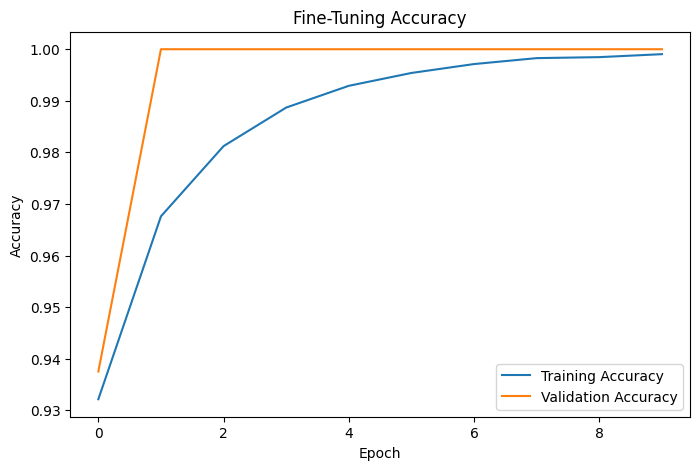

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.legend()

plt.show()

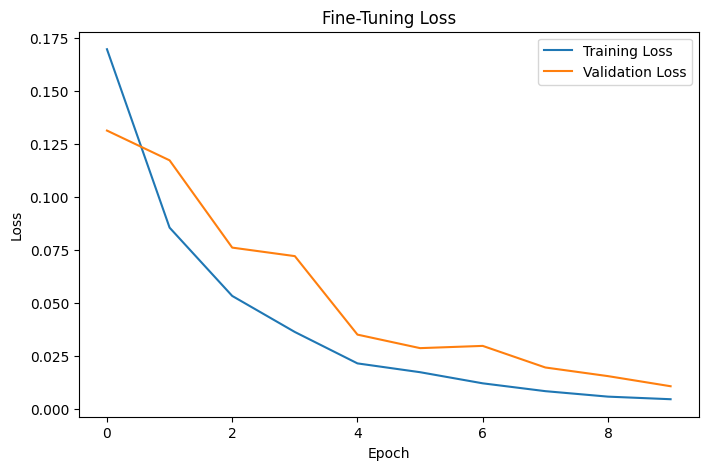

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss")
plt.legend()

plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = resnet_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Actual labels:", len(y_true))
print("Predicted labels:", len(y_pred))

Actual labels: 624
Predicted labels: 624


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      NORMAL       0.99      0.53      0.69       234
   PNEUMONIA       0.78      1.00      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.86      0.82      0.80       624



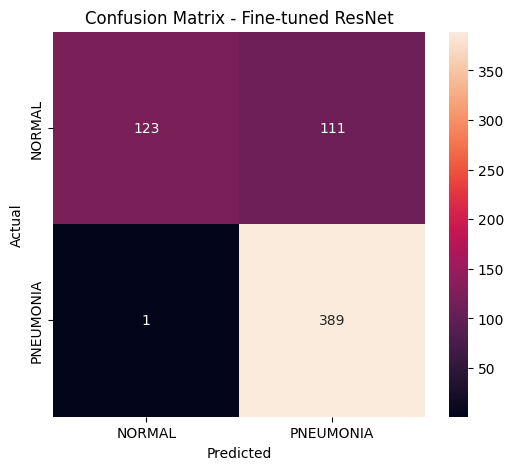

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fine-tuned ResNet")

plt.show()

In [ ]:
y_probability = []

for images, labels in test_ds:
    predictions = resnet_model.predict(images, verbose=0)

    pneumonia_probability = predictions[:, 1]

    y_probability.extend(pneumonia_probability)

y_probability = np.array(y_probability)

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_probability)

print("ROC-AUC:", auc)

ROC-AUC: 0.9173898750821828


In [ ]:
normal_count = len(os.listdir(dataset_path + "/train/NORMAL"))
pneumonia_count = len(os.listdir(dataset_path + "/train/PNEUMONIA"))

print("NORMAL:", normal_count)
print("PNEUMONIA:", pneumonia_count)

NORMAL: 1341
PNEUMONIA: 3875


In [ ]:
total = normal_count + pneumonia_count

class_weight = {
    0: total / (2 * normal_count),
    1: total / (2 * pneumonia_count)
}

print("Class weights:", class_weight)

Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [ ]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
weighted_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
weighted_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=[weighted_early_stopping]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 274ms/step - accuracy: 0.9990 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0073
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 256ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 257ms/step - accuracy: 0.9988 - loss: 0.0045 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 244ms/step - accuracy: 0.9988 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 248ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0056


In [ ]:
weighted_loss, weighted_accuracy = resnet_model.evaluate(test_ds)

print("Weighted ResNet Test Loss:", weighted_loss)
print("Weighted ResNet Test Accuracy:", weighted_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.8429 - loss: 1.0930
Weighted ResNet Test Loss: 1.0929759740829468
Weighted ResNet Test Accuracy: 0.8429487347602844


In [ ]:
y_true_weighted = []
y_pred_weighted = []

for images, labels in test_ds:
    predictions = resnet_model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true_weighted.extend(labels.numpy())
    y_pred_weighted.extend(predicted_classes)

y_true_weighted = np.array(y_true_weighted)
y_pred_weighted = np.array(y_pred_weighted)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_weighted,
        y_pred_weighted,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      NORMAL       0.99      0.59      0.74       234
   PNEUMONIA       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.90      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_weighted, y_pred_weighted)

print(cm)

[[137  97]
 [  1 389]]


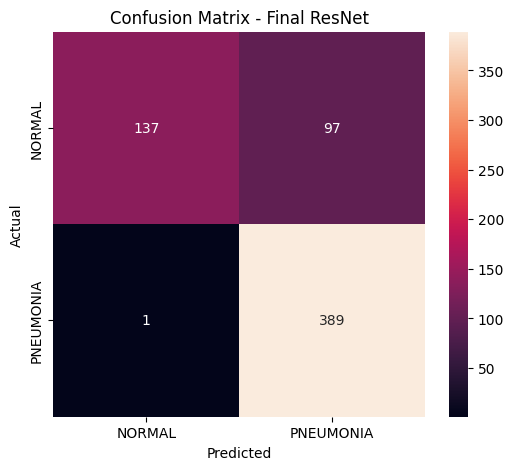

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final ResNet")

plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_true_weighted,
    y_pred_weighted
)

recall = recall_score(
    y_true_weighted,
    y_pred_weighted
)

f1 = f1_score(
    y_true_weighted,
    y_pred_weighted
)

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.8004115226337448
Recall    : 0.9974358974358974
F1 Score  : 0.8881278538812786


In [ ]:
y_probability_weighted = []

for images, labels in test_ds:
    predictions = resnet_model.predict(images, verbose=0)

    pneumonia_probability = predictions[:, 1]

    y_probability_weighted.extend(
        pneumonia_probability
    )

y_probability_weighted = np.array(
    y_probability_weighted
)

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_true_weighted,
    y_probability_weighted
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9156695156695156


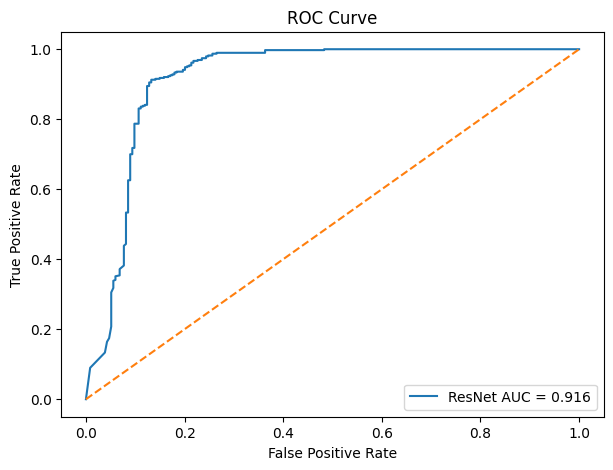

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_true_weighted,
    y_probability_weighted
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [ ]:
final_results = {
    "Basic CNN": test_accuracy,
    "Frozen ResNet": resnet_test_accuracy,
    "Fine-tuned ResNet": fine_tune_accuracy,
    "Weighted ResNet": weighted_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": auc
}

print(final_results)

{'Basic CNN': 0.75, 'Frozen ResNet': 0.8092948794364929, 'Fine-tuned ResNet': 0.8205128312110901, 'Weighted ResNet': 0.8429487347602844, 'Precision': 0.8004115226337448, 'Recall': 0.9974358974358974, 'F1 Score': 0.8881278538812786, 'ROC-AUC': np.float64(0.9156695156695156)}


In [ ]:
model_save_path = (
    project_path +
    "/models/pneumonia_resnet_final.keras"
)

resnet_model.save(model_save_path)

print("Model saved at:")
print(model_save_path)

Model saved at:
/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/models/pneumonia_resnet_final.keras


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def predict_xray(image_path):

    # Load image
    img = load_img(
        image_path,
        target_size=(img_height, img_width)
    )

    # Convert image to NumPy array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = resnet_model.predict(
        img_array,
        verbose=0
    )[0]

    # Get predicted class
    predicted_class = np.argmax(prediction)

    # Get confidence
    confidence = prediction[predicted_class] * 100

    return class_names[predicted_class], confidence

In [ ]:
normal_path = (
    dataset_path +
    "/test/NORMAL/" +
    test_normal[0]
)

result, confidence = predict_xray(normal_path)

print("Prediction:", result)
print("Confidence:", round(confidence, 2), "%")

Prediction: NORMAL
Confidence: 100.0 %


In [ ]:
pneumonia_path = (
    dataset_path +
    "/test/PNEUMONIA/" +
    test_pneumonia[0]
)

result, confidence = predict_xray(pneumonia_path)

print("Prediction:", result)
print("Confidence:", round(confidence, 2), "%")

Prediction: PNEUMONIA
Confidence: 99.98 %


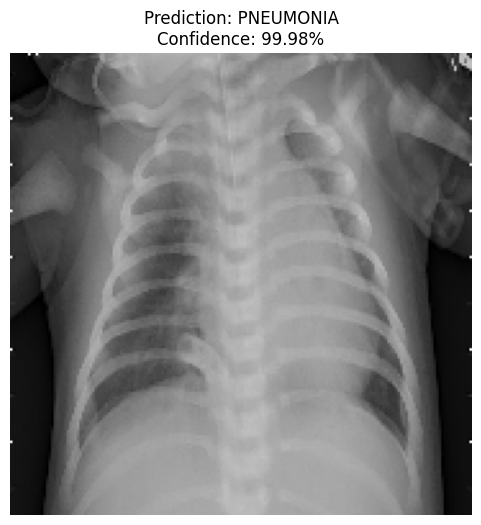

In [ ]:
img = load_img(
    pneumonia_path,
    target_size=(img_width, img_height)
)

plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.title(
    f"Prediction: {result}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

In [ ]:
correct = 0
total = 10

for i in range(total):

    image_path = (
        dataset_path +
        "/test/PNEUMONIA/" +
        test_pneumonia[i]
    )

    prediction, confidence = predict_xray(
        image_path
    )

    print(
        f"{i+1}. Actual: PNEUMONIA | "
        f"Predicted: {prediction} | "
        f"Confidence: {confidence:.2f}%"
    )

    if prediction == "PNEUMONIA":
        correct += 1

print("\nCorrect:", correct)
print("Total:", total)

1. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 99.98%
2. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 100.00%
3. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 100.00%
4. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 99.99%
5. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 100.00%
6. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 99.99%
7. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 100.00%
8. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 100.00%
9. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 100.00%
10. Actual: PNEUMONIA | Predicted: PNEUMONIA | Confidence: 100.00%

Correct: 10
Total: 10


In [ ]:
!pip install streamlit

In [ ]:
%%writefile /content/app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Page configuration
st.set_page_config(
    page_title="Pneumonia Detection",
    page_icon="🩻",
    layout="centered"
)

# Title
st.title("🩻 Chest X-Ray Pneumonia Detection")

st.write(
    "Upload a chest X-ray image and the trained "
    "ResNet model will predict NORMAL or PNEUMONIA."
)

# Model path
MODEL_PATH = "/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/models/pneumonia_resnet_final.keras"

# Load model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)

model = load_model()

# Upload image
uploaded_file = st.file_uploader(
    "Upload a Chest X-Ray",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file)

    st.image(
        image,
        caption="Uploaded Chest X-Ray",
        use_container_width=True
    )

    if st.button("Predict"):

        # Resize
        image = image.resize((180, 180))

        # Convert to array
        image_array = np.array(image)

        # Handle grayscale images
        if len(image_array.shape) == 2:
            image_array = np.stack(
                (image_array,) * 3,
                axis=-1
            )

        # Add batch dimension
        image_array = np.expand_dims(
            image_array,
            axis=0
        )

        # Prediction
        prediction = model.predict(
            image_array,
            verbose=0
        )[0]

        predicted_class = np.argmax(prediction)

        classes = [
            "NORMAL",
            "PNEUMONIA"
        ]

        result = classes[predicted_class]
        confidence = prediction[predicted_class] * 100

        st.subheader("Prediction")

        if result == "PNEUMONIA":
            st.error(
                f"Prediction: {result}"
            )
        else:
            st.success(
                f"Prediction: {result}"
            )

        st.write(
            f"Model confidence: {confidence:.2f}%"
        )

        st.warning(
            "This is an educational/research prototype "
            "and not a medical diagnosis."
        )

Overwriting /content/app.py


In [ ]:
!ls -l /content/app.py

-rw-r--r-- 1 root root 2175 Sep  4 09:27 /content/app.py


In [ ]:
!cp /content/app.py \
"/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/app/app.py"

In [ ]:
print("Model:", resnet_model)
print("Classes:", class_names)
print("Image Height:", img_height)
print("Image Width:", img_width)
print("Project Path:", project_path)

Model: <Sequential name=sequential_3, built=True>
Classes: ['NORMAL', 'PNEUMONIA']
Image Height: 180
Image Width: 180
Project Path: /content/drive/MyDrive/Chest_Xray_Pneumonia_Project


In [ ]:
import os

# Create required project folders
models_path = os.path.join(project_path, "models")
results_path = os.path.join(project_path, "results")
app_path = os.path.join(project_path, "app")

os.makedirs(models_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)
os.makedirs(app_path, exist_ok=True)

print("Folders created successfully!")
print("\nModels folder:", models_path)
print("Results folder:", results_path)
print("App folder:", app_path)

Folders created successfully!

Models folder: /content/drive/MyDrive/Chest_Xray_Pneumonia_Project/models
Results folder: /content/drive/MyDrive/Chest_Xray_Pneumonia_Project/results
App folder: /content/drive/MyDrive/Chest_Xray_Pneumonia_Project/app


In [ ]:
print("\nProject contents:")
print(os.listdir(project_path))


Project contents:
['dataset', 'notebook', 'models', 'results', 'app']


In [ ]:
model_save_path = os.path.join(
    models_path,
    "pneumonia_resnet_final.keras"
)

# Save the trained model
resnet_model.save(model_save_path)

print("Model saved successfully!")
print("Model path:", model_save_path)

Model saved successfully!
Model path: /content/drive/MyDrive/Chest_Xray_Pneumonia_Project/models/pneumonia_resnet_final.keras


In [ ]:
print(os.listdir(models_path))

['pneumonia_resnet_final.keras']


In [ ]:
print("Checking model file...")

if os.path.exists(model_save_path):
    print("SUCCESS: Model file exists!")
    print("Location:", model_save_path)
else:
    print("ERROR: Model file was not found.")

Checking model file...
SUCCESS: Model file exists!
Location: /content/drive/MyDrive/Chest_Xray_Pneumonia_Project/models/pneumonia_resnet_final.keras


In [ ]:
import tensorflow as tf

# Load the saved model
loaded_model = tf.keras.models.load_model(model_save_path)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
loaded_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 6, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,331,400 (207.26 MB)

 Trainable params: 15,240,578 (58.14 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

 Optimizer params: 30,481,158 (116.28 MB)

In [ ]:
print("Original model input shape:", resnet_model.input_shape)
print("Loaded model input shape:", loaded_model.input_shape)

print("Original model output shape:", resnet_model.output_shape)
print("Loaded model output shape:", loaded_model.output_shape)

Original model input shape: (None, 180, 180, 3)
Loaded model input shape: (None, 180, 180, 3)
Original model output shape: (None, 2)
Loaded model output shape: (None, 2)


In [ ]:
import os
import glob

# Get NORMAL test images
normal_images = glob.glob(
    os.path.join(
        project_path,
        "dataset",
        "chest_xray",
        "test",
        "NORMAL",
        "*"
    )
)

# Get PNEUMONIA test images
pneumonia_images = glob.glob(
    os.path.join(
        project_path,
        "dataset",
        "chest_xray",
        "test",
        "PNEUMONIA",
        "*"
    )
)

print("Normal images found:", len(normal_images))
print("Pneumonia images found:", len(pneumonia_images))

Normal images found: 234
Pneumonia images found: 390


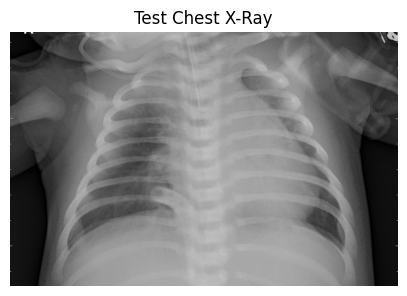

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Select one image
test_image_path = pneumonia_images[0]

# Display the image
img = load_img(test_image_path)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Test Chest X-Ray")
plt.show()

In [ ]:
# Load image with the same size used during training
img = load_img(
    test_image_path,
    target_size=(img_height, img_width)
)

# Convert image to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(
    img_array,
    axis=0
)

# Predict
prediction = loaded_model.predict(
    img_array,
    verbose=0
)

print("Raw prediction:", prediction)

# Get predicted class
predicted_index = np.argmax(prediction[0])

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("\nPredicted Class:", predicted_class)
print("Confidence:", round(float(confidence), 2), "%")

Raw prediction: [[1.8152088e-04 9.9981844e-01]]

Predicted Class: PNEUMONIA
Confidence: 99.98 %


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

def predict_xray(image_path, model=loaded_model):

    # Load image with same size used during training
    img = load_img(
        image_path,
        target_size=(img_height, img_width)
    )

    # Convert image to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Make prediction
    predictions = model.predict(
        img_array,
        verbose=0
    )[0]

    # Get predicted class index
    predicted_index = np.argmax(predictions)

    # Get class name
    predicted_class = class_names[predicted_index]

    # Calculate probabilities
    confidence = float(
        predictions[predicted_index] * 100
    )

    normal_probability = float(
        predictions[0] * 100
    )

    pneumonia_probability = float(
        predictions[1] * 100
    )

    # Return all results
    return {
        "prediction": predicted_class,
        "confidence": confidence,
        "normal_probability": normal_probability,
        "pneumonia_probability": pneumonia_probability
    }

In [ ]:
result = predict_xray(test_image_path)

print("Prediction:", result["prediction"])
print(
    "Confidence:",
    round(result["confidence"], 2),
    "%"
)

print(
    "NORMAL Probability:",
    round(result["normal_probability"], 2),
    "%"
)

print(
    "PNEUMONIA Probability:",
    round(result["pneumonia_probability"], 2),
    "%"
)

Prediction: PNEUMONIA
Confidence: 99.98 %
NORMAL Probability: 0.02 %
PNEUMONIA Probability: 99.98 %


In [ ]:
normal_test_image = normal_images[0]

result = predict_xray(normal_test_image)

print(result)

{'prediction': 'NORMAL', 'confidence': 99.99705505371094, 'normal_probability': 99.99705505371094, 'pneumonia_probability': 0.00294157094322145}


In [ ]:
import os

# Create models folder
models_path = os.path.join(
    project_path,
    "models"
)

os.makedirs(
    models_path,
    exist_ok=True
)

# Path where final model will be saved
model_save_path = os.path.join(
    models_path,
    "pneumonia_resnet_final.keras"
)

# Save your final trained ResNet model
resnet_model.save(
    model_save_path
)

print("Model saved successfully!")
print("Saved at:")
print(model_save_path)

Model saved successfully!
Saved at:
/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/models/pneumonia_resnet_final.keras


In [ ]:
print(os.path.exists(model_save_path))

True


In [ ]:
import tensorflow as tf

# Load the saved model
loaded_model = tf.keras.models.load_model(
    model_save_path
)

print("Model loaded successfully!")
print("Model input shape:", loaded_model.input_shape)
print("Model output shape:", loaded_model.output_shape)

Model loaded successfully!
Model input shape: (None, 180, 180, 3)
Model output shape: (None, 2)


In [ ]:
# Test prediction using the loaded model
test_predictions = loaded_model.predict(
    test_ds,
    verbose=1
)

print("Prediction completed!")
print("Prediction shape:", test_predictions.shape)

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 791ms/step
Prediction completed!
Prediction shape: (624, 2)


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from the test dataset
y_true = np.concatenate([
    y.numpy()
    for _, y in test_ds
])

# Convert model predictions to class labels
y_pred = np.argmax(
    test_predictions,
    axis=1
)

# Generate classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      NORMAL       0.99      0.59      0.74       234
   PNEUMONIA       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.90      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



In [ ]:
import os
import pandas as pd

# Create results folder
results_path = os.path.join(
    project_path,
    "results"
)

os.makedirs(
    results_path,
    exist_ok=True
)

# Create report as dataframe
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

# Save report
report_path = os.path.join(
    results_path,
    "classification_report.csv"
)

report_df.to_csv(
    report_path
)

print("Classification report saved!")
print(report_path)

Classification report saved!
/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/results/classification_report.csv


In [ ]:
print(
    os.listdir(results_path)
)

['classification_report.csv', 'confusion_matrix.png', 'final_metrics.csv', 'roc_curve.png', 'model_comparison.png', 'gradcam_examples.png', 'pr_curve.png', 'misclassified_examples.png']


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[137  97]
 [  1 389]]


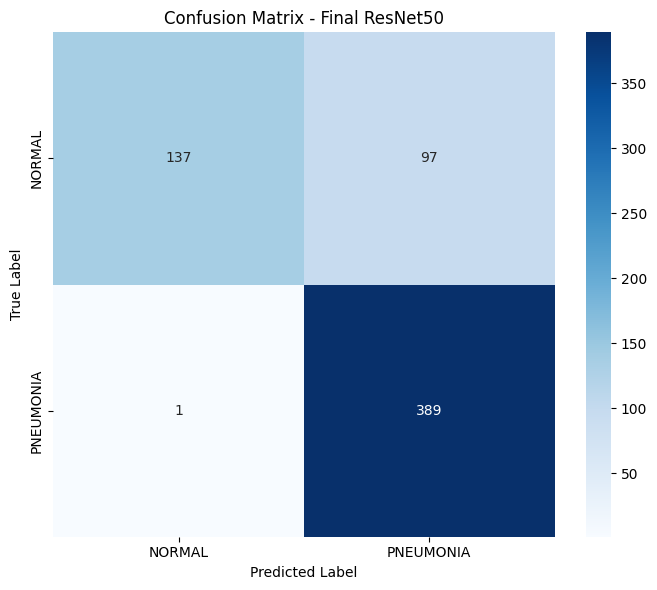

In [ ]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final ResNet50")

plt.tight_layout()

plt.show()

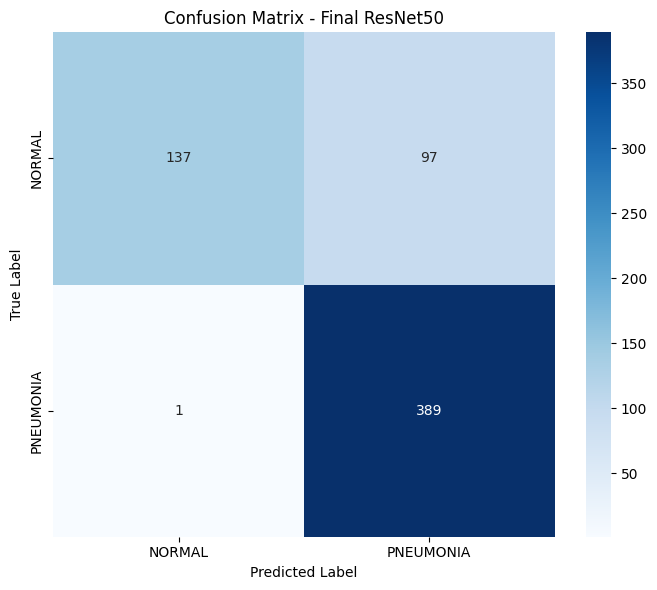

Confusion matrix saved!
/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/results/confusion_matrix.png


In [ ]:
cm_path = os.path.join(
    results_path,
    "confusion_matrix.png"
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final ResNet50")

plt.tight_layout()

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved!")
print(cm_path)

In [ ]:
print(os.listdir(results_path))

['classification_report.csv', 'confusion_matrix.png', 'final_metrics.csv', 'roc_curve.png', 'model_comparison.png', 'gradcam_examples.png', 'pr_curve.png', 'misclassified_examples.png']


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Accuracy
accuracy = accuracy_score(
    y_true,
    y_pred
)

# Precision
precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

# Recall
recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

# F1 Score
f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

# ROC-AUC
# Use probability of the PNEUMONIA class
pneumonia_probabilities = test_predictions[:, 1]

roc_auc = roc_auc_score(
    y_true,
    pneumonia_probabilities
)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("=" * 50)

FINAL MODEL PERFORMANCE
Accuracy  : 0.8429
Precision : 0.8004
Recall    : 0.9974
F1 Score  : 0.8881
ROC-AUC   : 0.9157


In [ ]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

final_metrics

,Metric,Value
0,Accuracy,0.842949
1,Precision,0.800412
2,Recall,0.997436
3,F1 Score,0.888128
4,ROC-AUC,0.915670


In [ ]:
metrics_path = os.path.join(
    results_path,
    "final_metrics.csv"
)

final_metrics.to_csv(
    metrics_path,
    index=False
)

print("Final metrics saved!")
print(metrics_path)

Final metrics saved!
/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/results/final_metrics.csv


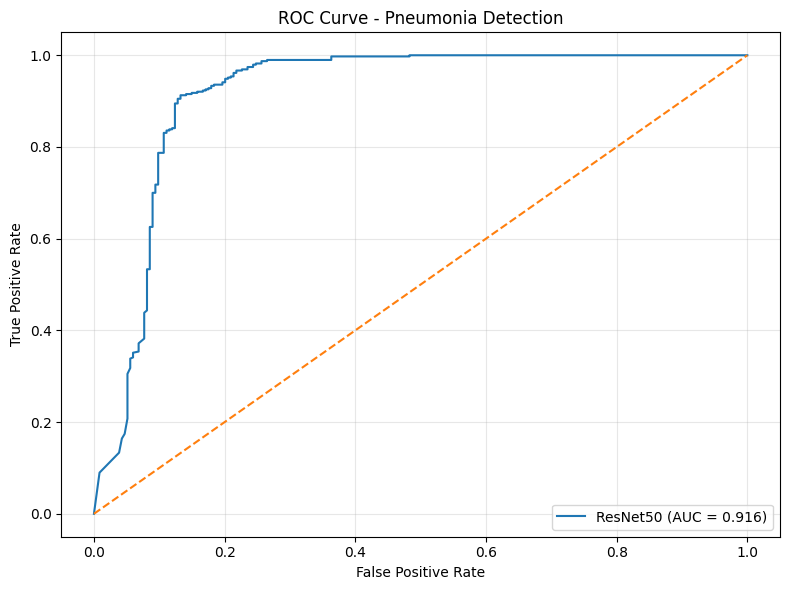

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_true,
    pneumonia_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet50 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Pneumonia Detection"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
roc_path = os.path.join(
    results_path,
    "roc_curve.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)

print("ROC curve saved!")
print(roc_path)

ROC curve saved!
/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/results/roc_curve.png


<Figure size 640x480 with 0 Axes>

In [ ]:
print("RESULT FILES")
print("=" * 40)

for file in os.listdir(results_path):
    print("✓", file)

RESULT FILES
✓ classification_report.csv
✓ confusion_matrix.png
✓ final_metrics.csv
✓ roc_curve.png
✓ model_comparison.png
✓ gradcam_examples.png
✓ pr_curve.png
✓ misclassified_examples.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

model_comparison = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "Frozen ResNet50",
        "Fine-Tuned ResNet50",
        "Weighted ResNet50"
    ],
    "Accuracy": [
        test_accuracy,
        resnet_test_accuracy,
        fine_tune_accuracy,
        weighted_accuracy
    ]
})

display(model_comparison)

,Model,Accuracy
0,Basic CNN,0.750000
1,Frozen ResNet50,0.809295
2,Fine-Tuned ResNet50,0.820513
3,Weighted ResNet50,0.842949


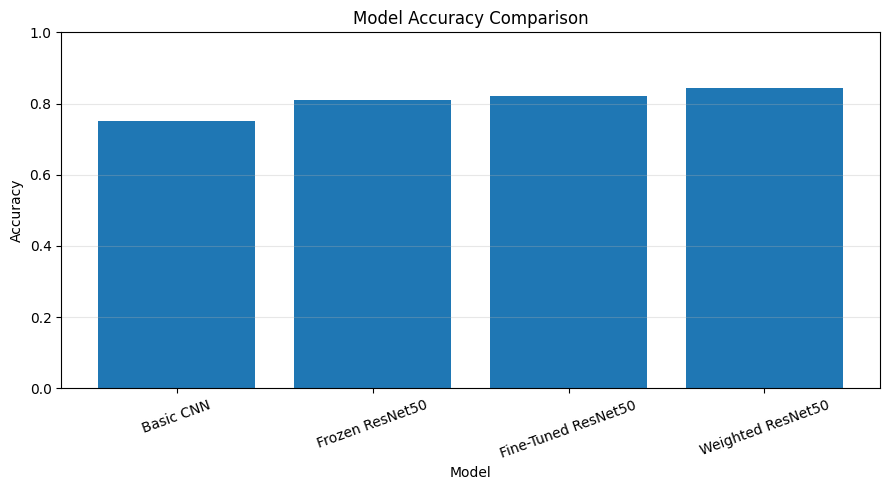

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

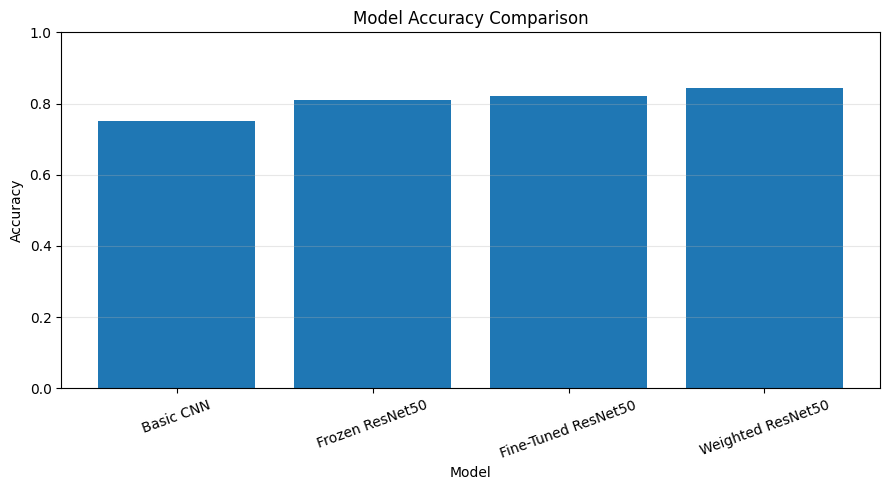

Model comparison graph saved!
/content/drive/MyDrive/Chest_Xray_Pneumonia_Project/results/model_comparison.png


In [ ]:
comparison_path = os.path.join(
    results_path,
    "model_comparison.png"
)

plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()

print("Model comparison graph saved!")
print(comparison_path)

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

def predict_xray(image_path):
    # Load image
    img = load_img(
        image_path,
        target_size=(img_height, img_width)
    )

    # Convert image to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Get prediction
    prediction = loaded_model.predict(img_array, verbose=0)[0]

    # Get predicted class
    predicted_class = np.argmax(prediction)

    # Get confidence
    confidence = prediction[predicted_class] * 100

    return class_names[predicted_class], confidence

In [ ]:
import os

normal_folder = os.path.join(dataset_path, "test", "NORMAL")
pneumonia_folder = os.path.join(dataset_path, "test", "PNEUMONIA")

normal_image = os.listdir(normal_folder)[0]
pneumonia_image = os.listdir(pneumonia_folder)[0]

normal_path = os.path.join(normal_folder, normal_image)
pneumonia_path = os.path.join(pneumonia_folder, pneumonia_image)

print("NORMAL image:")
print(predict_xray(normal_path))

print("\nPNEUMONIA image:")
print(predict_xray(pneumonia_path))

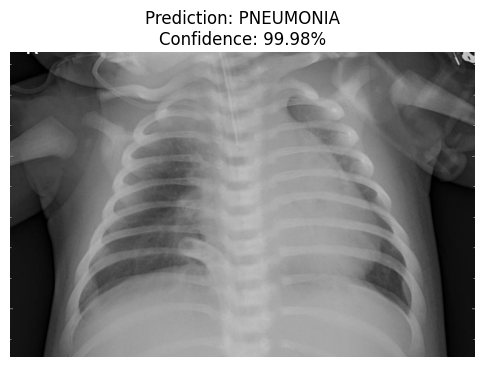

In [ ]:
image_path = pneumonia_path

predicted_class, confidence = predict_xray(image_path)

img = load_img(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()

In [ ]:
def predict_xray(image_path):
    # Load and resize image
    img = load_img(
        image_path,
        target_size=(img_height, img_width)
    )

    # Convert image to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = loaded_model.predict(
        img_array,
        verbose=0
    )[0]

    # Get probabilities
    normal_probability = float(prediction[0])
    pneumonia_probability = float(prediction[1])

    # Get predicted class
    predicted_class_index = np.argmax(prediction)
    predicted_class = class_names[predicted_class_index]

    # Confidence
    confidence = float(prediction[predicted_class_index])

    return {
        "prediction": predicted_class,
        "confidence": confidence,
        "normal_probability": normal_probability,
        "pneumonia_probability": pneumonia_probability
    }

In [ ]:
result = predict_xray(pneumonia_path)

print("Prediction:", result["prediction"])
print("Confidence:", f"{result['confidence'] * 100:.2f}%")
print("NORMAL Probability:", f"{result['normal_probability'] * 100:.2f}%")
print("PNEUMONIA Probability:", f"{result['pneumonia_probability'] * 100:.2f}%")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import os
from tensorflow.keras.utils import load_img, img_to_array

# --- Setup: split the model into (resnet base) + (classifier head) ---
resnet_base = loaded_model.get_layer("resnet50")
last_conv_layer_name = "conv5_block3_3_conv"

grad_model = tf.keras.models.Model(
    inputs=resnet_base.input,
    outputs=[
        resnet_base.get_layer(last_conv_layer_name).output,
        resnet_base.output
    ]
)

classifier_layers = loaded_model.layers[1:]  # GAP, Dropout, Dense128, Dropout, Dense2


def make_gradcam_heatmap(img_array, pred_index=None):
    with tf.GradientTape() as tape:
        conv_output, resnet_output = grad_model(img_array)
        tape.watch(conv_output)

        x = resnet_output
        for layer in classifier_layers:
            x = layer(x)
        predictions = x

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), predictions.numpy()[0]


def overlay_gradcam(image_path, alpha=0.4):
    img = load_img(image_path, target_size=(img_height, img_width))
    img_array = img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    heatmap, predictions = make_gradcam_heatmap(img_batch)

    heatmap_resized = cv2.resize(heatmap, (img_width, img_height))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = np.uint8(jet_colors[heatmap_uint8] * 255)

    superimposed = np.clip(jet_heatmap * alpha + img_array, 0, 255).astype("uint8")

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index] * 100

    return img_array.astype("uint8"), superimposed, predicted_class, confidence


# --- Run on a few sample images and display side by side ---
sample_images = [
    (dataset_path + "/test/NORMAL/" + test_normal[0], "NORMAL"),
    (dataset_path + "/test/NORMAL/" + test_normal[1], "NORMAL"),
    (dataset_path + "/test/PNEUMONIA/" + test_pneumonia[0], "PNEUMONIA"),
    (dataset_path + "/test/PNEUMONIA/" + test_pneumonia[1], "PNEUMONIA"),
]

fig, axes = plt.subplots(len(sample_images), 2, figsize=(8, 4 * len(sample_images)))

for i, (path, actual_label) in enumerate(sample_images):
    original, overlay, predicted_class, confidence = overlay_gradcam(path)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Actual: {actual_label}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(f"Grad-CAM\nPred: {predicted_class} ({confidence:.1f}%)")
    axes[i, 1].axis("off")

plt.tight_layout()
gradcam_path = os.path.join(results_path, "gradcam_examples.png")
plt.savefig(gradcam_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", gradcam_path)

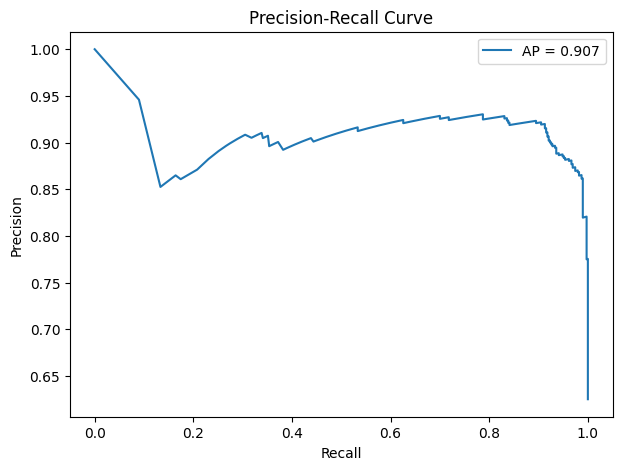

Total misclassified: 98 / 624


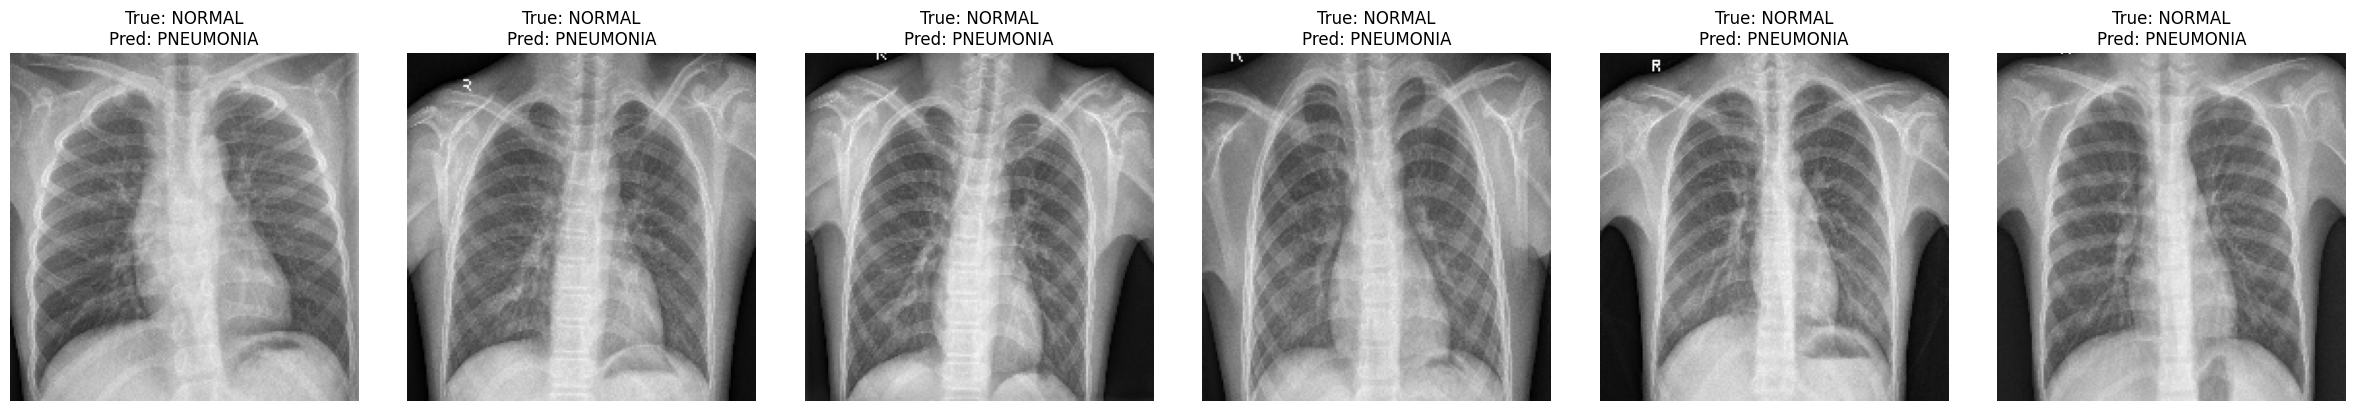

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

pneumonia_probabilities = test_predictions[:, 1]
precisions, recalls, _ = precision_recall_curve(y_true, pneumonia_probabilities)
ap_score = average_precision_score(y_true, pneumonia_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.savefig(os.path.join(results_path, "pr_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- Misclassified examples ---
y_pred = np.argmax(test_predictions, axis=1)
file_paths = test_ds.file_paths  # matches order since shuffle=False

misclassified_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true)}")

n_show = min(6, len(misclassified_idx))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))

for ax, idx in zip(axes, misclassified_idx[:n_show]):
    img = load_img(file_paths[idx], target_size=(img_height, img_width))
    ax.imshow(img)
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(results_path, "misclassified_examples.png"), dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
print(os.listdir(results_path))